In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", font="DejaVu Serif") #TODO: fix with actual thesis font

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

main_folder = {
    "Native": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/",
    "SME": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/",
    "SME+SEV": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
    "Native_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
    "SME_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
    "SME+SEV_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}

# Data Validity per Iter

In [25]:
config_cols_iter = ['Mode', 'MB', 'Randomness', 'Cores', 'VM_NUMA', 'Process_NUMA']
iter_list = []

for label, base_path in main_folder.items():
    extra_path = os.path.join(base_path, "extra")
    
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            it_df['Mode'] = label.replace("_interleave", "")
            it_df['Randomness'] = float(match.group(1).replace('-', '.'))
            it_df['N'] = int(match.group(2))
            it_df['Cores'] = int(match.group(3))
            it_df['Process_NUMA'] = match.group(4)
            it_df['VM_NUMA'] = "interleave" if "interleave" in label else "strict"
            it_df['MB'] = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            iter_list.append(it_df)


# This takes ~3 minutes
df_iters = pd.concat(iter_list, ignore_index=True).groupby(config_cols_iter + ['Iter']).median().reset_index()
print(f"Loaded {len(df_iters)*15} individual iterations. Median computed for {len(df_iters)} data points.")

Loaded 408661650 individual iterations. Median computed for 27244110 data points.


In [26]:
def get_config_stability(group, window_size=15, threshold_pct=3.0, warmup_tol=0.05, stable_window=5):
    times = group['Time'].values
    n = len(times)

    if n < window_size:
        return pd.Series({
            "Warmup_Iters": np.nan,
            "Warmup_Pct": np.nan,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": True,
            "Too_Small": True
        })

    ref = np.median(times)
    rel_err = np.abs((times - ref) / ref)

    # --- find first stable region
    warmup_end = None
    for i in range(0, n - stable_window + 1):
        if np.all(rel_err[i:i+stable_window] <= warmup_tol):
            warmup_end = i
            break

    if warmup_end is None:
        return pd.Series({
            "Warmup_Iters": np.nan,
            "Warmup_Pct": np.nan,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": False,
            "Too_Small": False
        })

    # ---  cut warmup
    stable_times = times[warmup_end:]

    if len(stable_times) < window_size:
        return pd.Series({
            "Warmup_Iters": warmup_end,
            "Warmup_Pct": warmup_end / n * 100,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": True,
            "Too_Small": True
        })

    # --- stability after warmup
    rolling = pd.Series(stable_times).rolling(window=window_size, center=True).mean()
    valid = rolling.dropna()

    global_med = np.median(stable_times)

    p2p_shift = (np.percentile(valid, 98) - np.percentile(valid, 2)) / global_med * 100

    return pd.Series({
        "Warmup_Iters": int(warmup_end),
        "Warmup_Pct": warmup_end / n * 100,
        "P2P_Shift_Pct": p2p_shift,
        "Is_Stable": p2p_shift < threshold_pct,
        "Too_Small": False
    })


stability_report = df_iters.groupby(config_cols_iter).apply(get_config_stability, include_groups=False).reset_index()

In [27]:
stability_report["Too_Small"].value_counts()

Too_Small
False    468
True      12
Name: count, dtype: int64

In [28]:
stability_report["Warmup_Pct"].describe()

count    468.000000
mean       0.084496
std        0.196148
min        0.000000
25%        0.000000
50%        0.006547
75%        0.062539
max        1.204819
Name: Warmup_Pct, dtype: float64

In [29]:
#before looking at the stability results, lets look at those with too few iterations 
few_iter = df_iters.merge( stability_report[stability_report["Too_Small"]], on=config_cols_iter, how='inner')

def get_stats(group):
    y = group['Time'].values
    x = np.arange(len(y))
    
    slope = np.polyfit(x, y, 1)[0]
    slope_pct = (slope / np.mean(y)) * 100
    
    cv = (np.std(y) / np.mean(y)) * 100
    range_pct = ((np.max(y) - np.min(y)) / np.mean(y)) * 100
    
    return pd.Series({
        "Slope_Pct": slope_pct,
        "CV_Pct": cv,
        "Range_Pct": range_pct
    })

few_iter_stats = few_iter.groupby(config_cols_iter).apply(get_stats, include_groups=False).reset_index()
print(f"Max slope: {few_iter_stats['Slope_Pct'].abs().max():.4f}%")
print(f"Max CV: {few_iter_stats['CV_Pct'].abs().max():.4f}%")
print(f"Max Range: {few_iter_stats['Range_Pct'].abs().max():.4f}%")
# Those configs were already set to Is_Stable = True, nothing to change there

Max slope: 0.0157%
Max CV: 0.0365%
Max Range: 0.1066%


In [30]:
stability_report["Is_Stable"].value_counts()

Is_Stable
True     470
False     10
Name: count, dtype: int64

In [31]:
#downsampling for plotting
def downsample(df, group_cols, n_points=200):
    def process_config(config_group):

        unique_iters = np.sort(config_group['Iter'].unique())

        if len(unique_iters) <= n_points:
            target_iters = unique_iters
        else:
            idx = np.linspace(0, len(unique_iters) - 1, n_points).astype(int)
            target_iters = unique_iters[idx]

        # Select the sampled iterations
        sampled = config_group[config_group['Iter'].isin(target_iters)].copy()

        # Keep one row per iteration (already median-aggregated upstream)
        sampled = sampled.sort_values('Iter')

        # Normalize iteration index
        sampled["IterNorm"] = np.linspace(0, 1, len(sampled))

        return sampled

    return df.groupby(group_cols, group_keys=False).apply(process_config).reset_index(drop=True)

df_iters_small = downsample(df_iters, group_cols=config_cols_iter, n_points=200)
print(f"Downsampled to {len(df_iters_small)} rows")

Downsampled to 85548 rows


/tmp/ipykernel_1635114/1610360081.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(process_config).reset_index(drop=True)


Mode
SME        4
SME+SEV    4
Native     2
Name: count, dtype: int64 MB
70    10
Name: count, dtype: int64 Cores
1    10
Name: count, dtype: int64 Randomness
1.0    10
Name: count, dtype: int64
Average Max Plateau Shift Impact (%): 9.928312792762966


/tmp/ipykernel_1635114/1182421952.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison_df['Is_Plateau_Config'] = comparison_df['Is_Plateau_Config'].fillna(False)


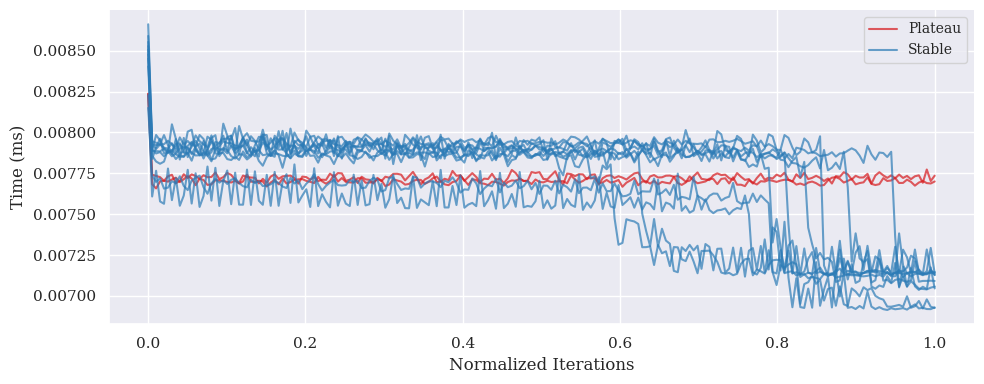

In [58]:
not_straight_large = stability_report[(~stability_report["Is_Stable"]) & (~stability_report["Too_Small"])]
print(not_straight_large["Mode"].value_counts(), not_straight_large["MB"].value_counts(), not_straight_large["Cores"].value_counts(), not_straight_large["Randomness"].value_counts())
print("Average Max Plateau Shift Impact (%):", not_straight_large["P2P_Shift_Pct"].mean())

# "Problematic" Configuration
comparison_df = df_iters_small[ (df_iters_small['MB'] == 70) & (df_iters_small['Cores'] == 1) & (df_iters_small['Randomness'] == 1) ].copy()

# Identify shifted keys in the comparison DataFrame to visualize them with another color
shifted_keys = not_straight_large.merge( comparison_df[config_cols_iter], on=config_cols_iter)[config_cols_iter].drop_duplicates()
comparison_df = comparison_df.merge( shifted_keys.assign(Is_Plateau_Config=True), on=config_cols_iter, how='left')
comparison_df['Is_Plateau_Config'] = comparison_df['Is_Plateau_Config'].fillna(False)

# Define the Display Category
comparison_df['Display_Group'] = np.where(
    comparison_df['Is_Plateau_Config'], 
    "Stable", 
    "Plateau"
)

# 4. Unique ID for individual lines
comparison_df['Config_Line_ID'] = comparison_df[config_cols_iter].astype(str).agg('-'.join, axis=1)

plt.figure(figsize=(10, 4)) 

# 2. Use lineplot (Axes-level) instead of relplot
sns.lineplot(
    data=comparison_df,
    x="IterNorm",
    y="Time",
    hue="Display_Group",
    units="Config_Line_ID",
    estimator=None, 
    palette={
        "Plateau": "#d7191c",
        "Stable": "#2c7bb6",    
    },
    alpha=0.7,      
)

# 3. Compact Legend inside the plot
# 'upper left' or 'lower right' usually works best depending on your data curve
plt.legend(title=None, frameon=True, fontsize='small')

# 4. Clean labels
plt.xlabel("Normalized Iterations")
plt.ylabel("Time (ms)")

# 5. Remove top/right spines for a modern look
sns.despine()

plt.tight_layout()
plt.savefig("images/SpMV_Stability_Comparison.pdf", bbox_inches='tight')

#Plateau shift happens between about 60 and 90% of iterations

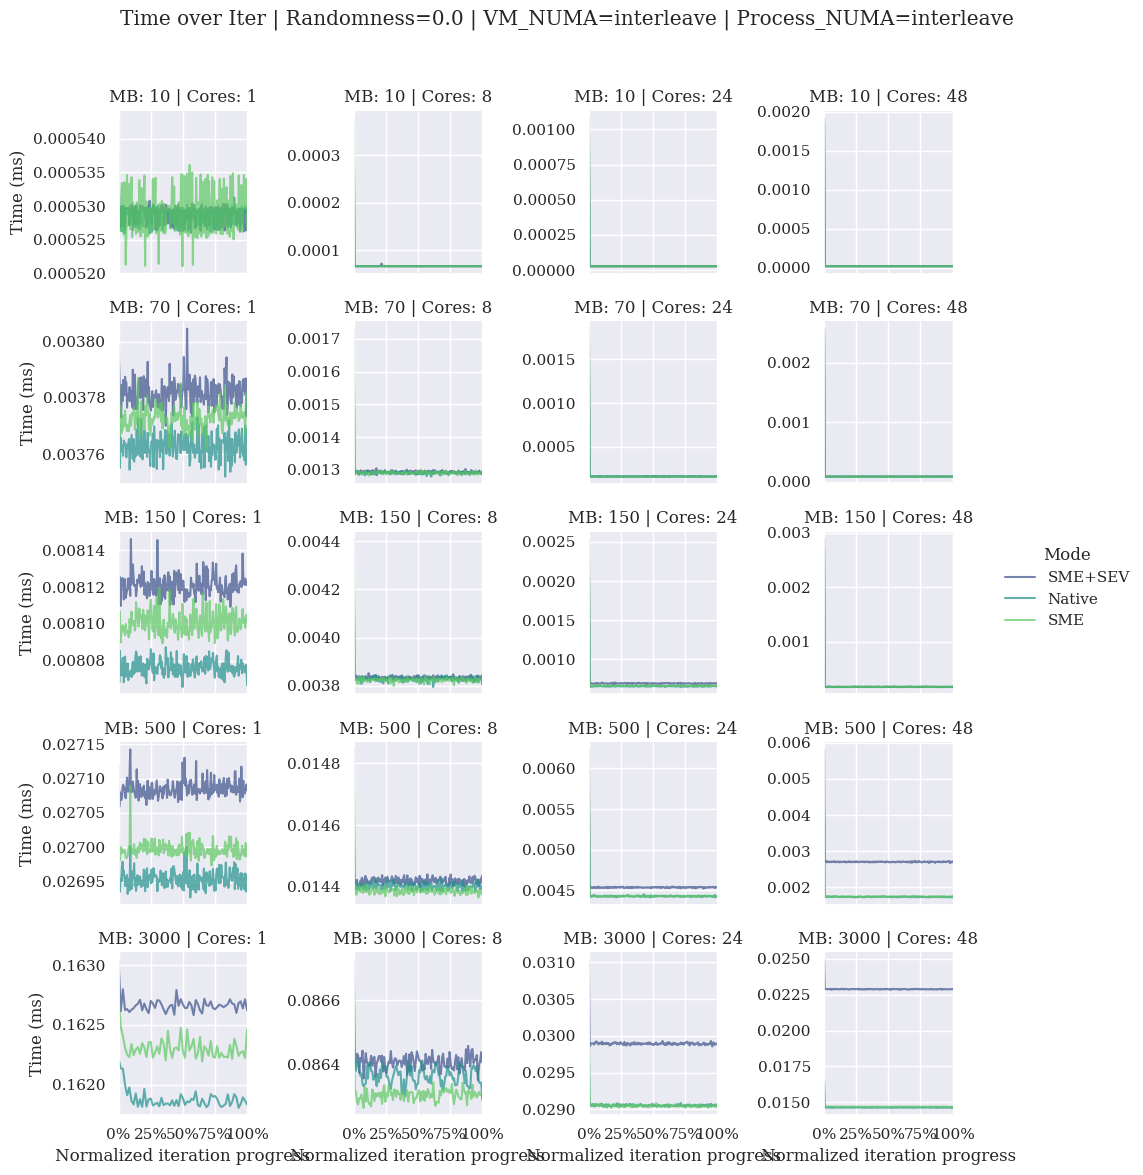

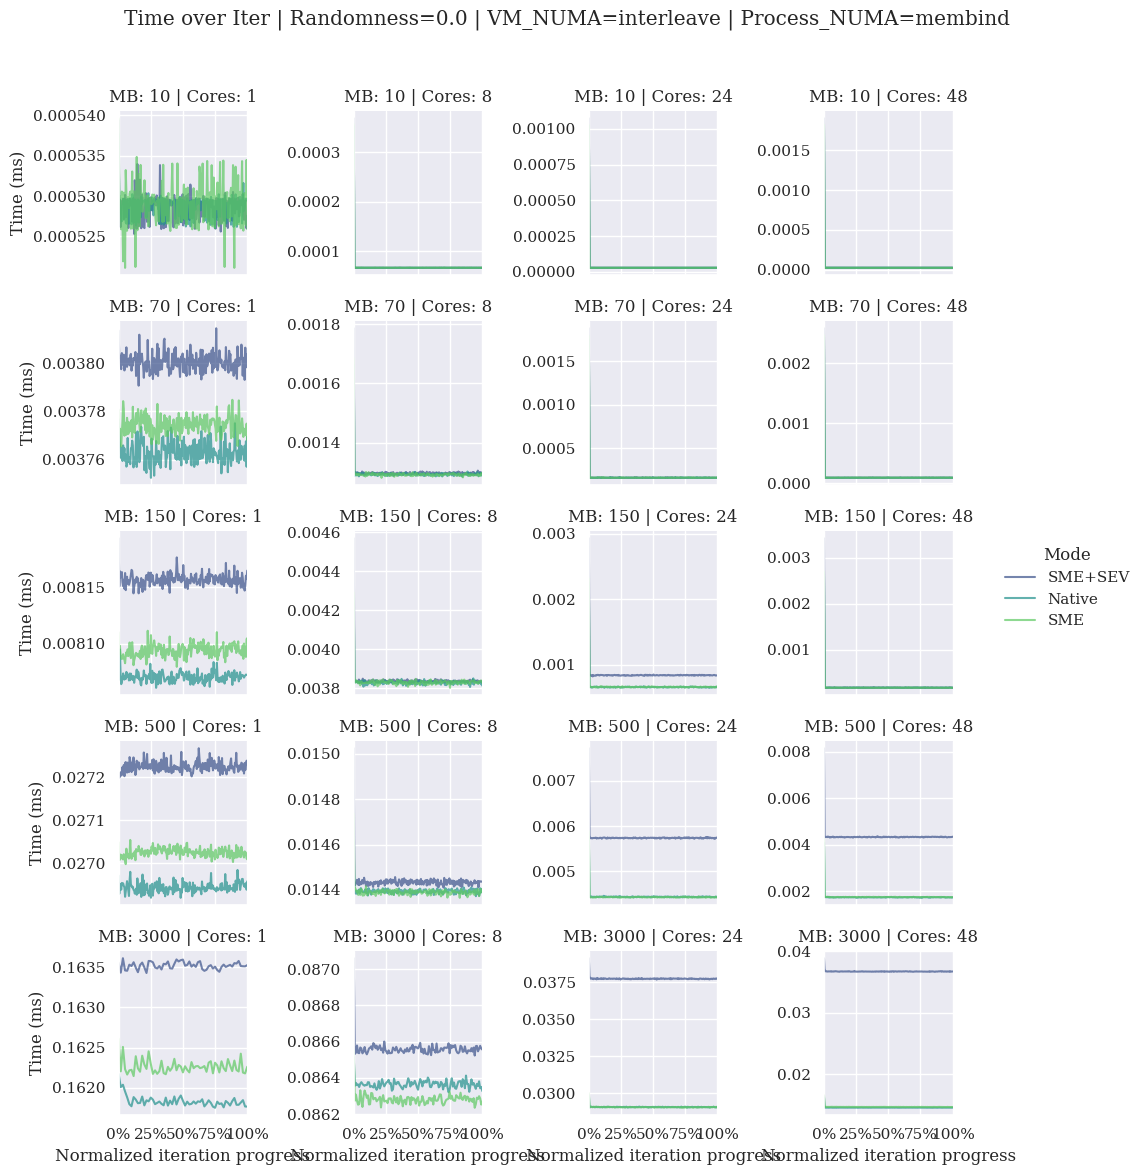

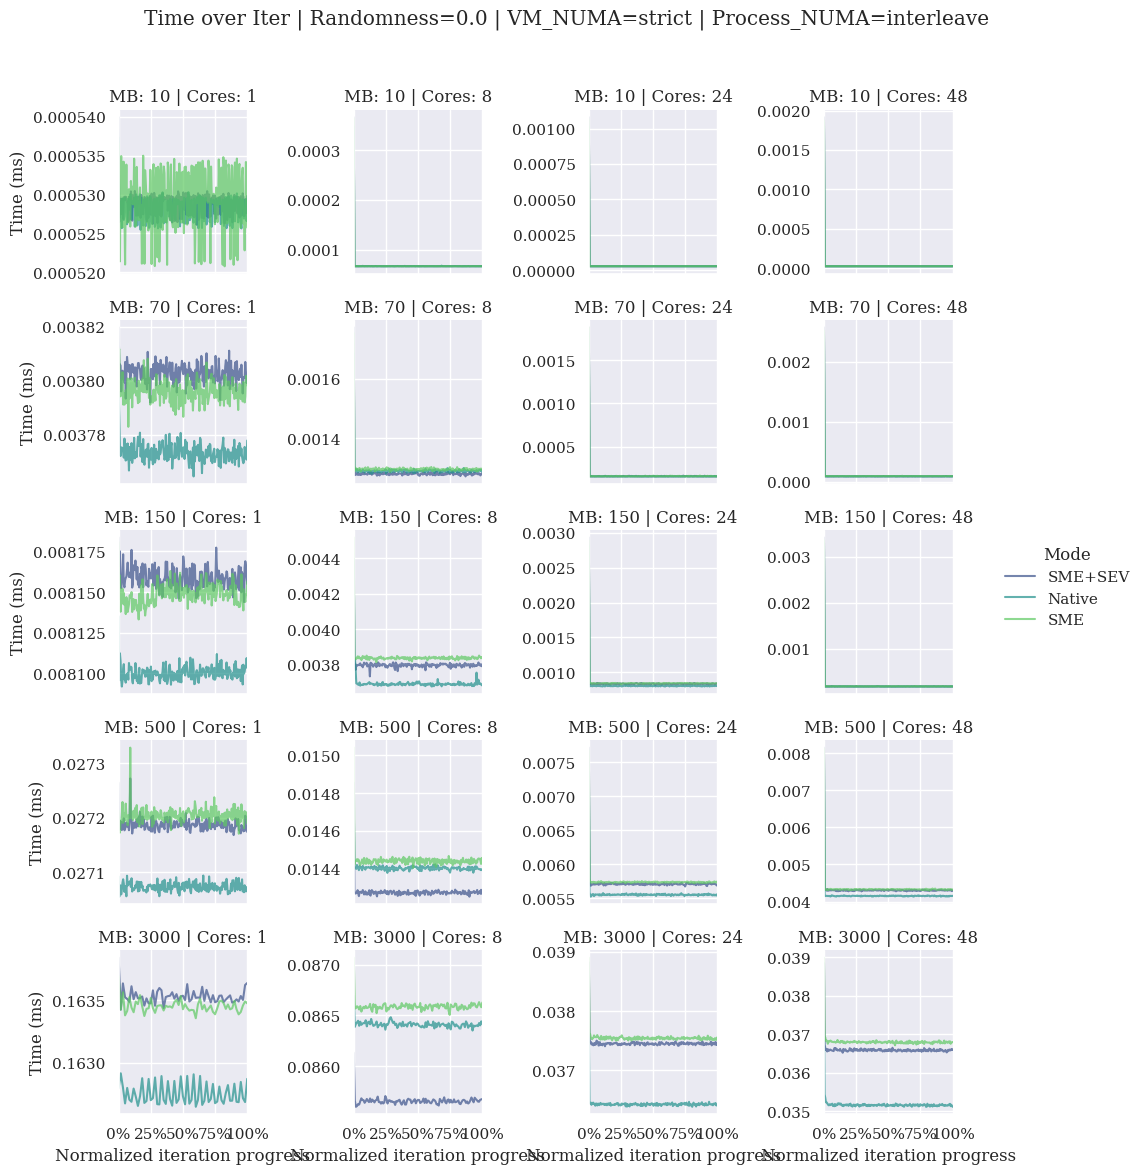

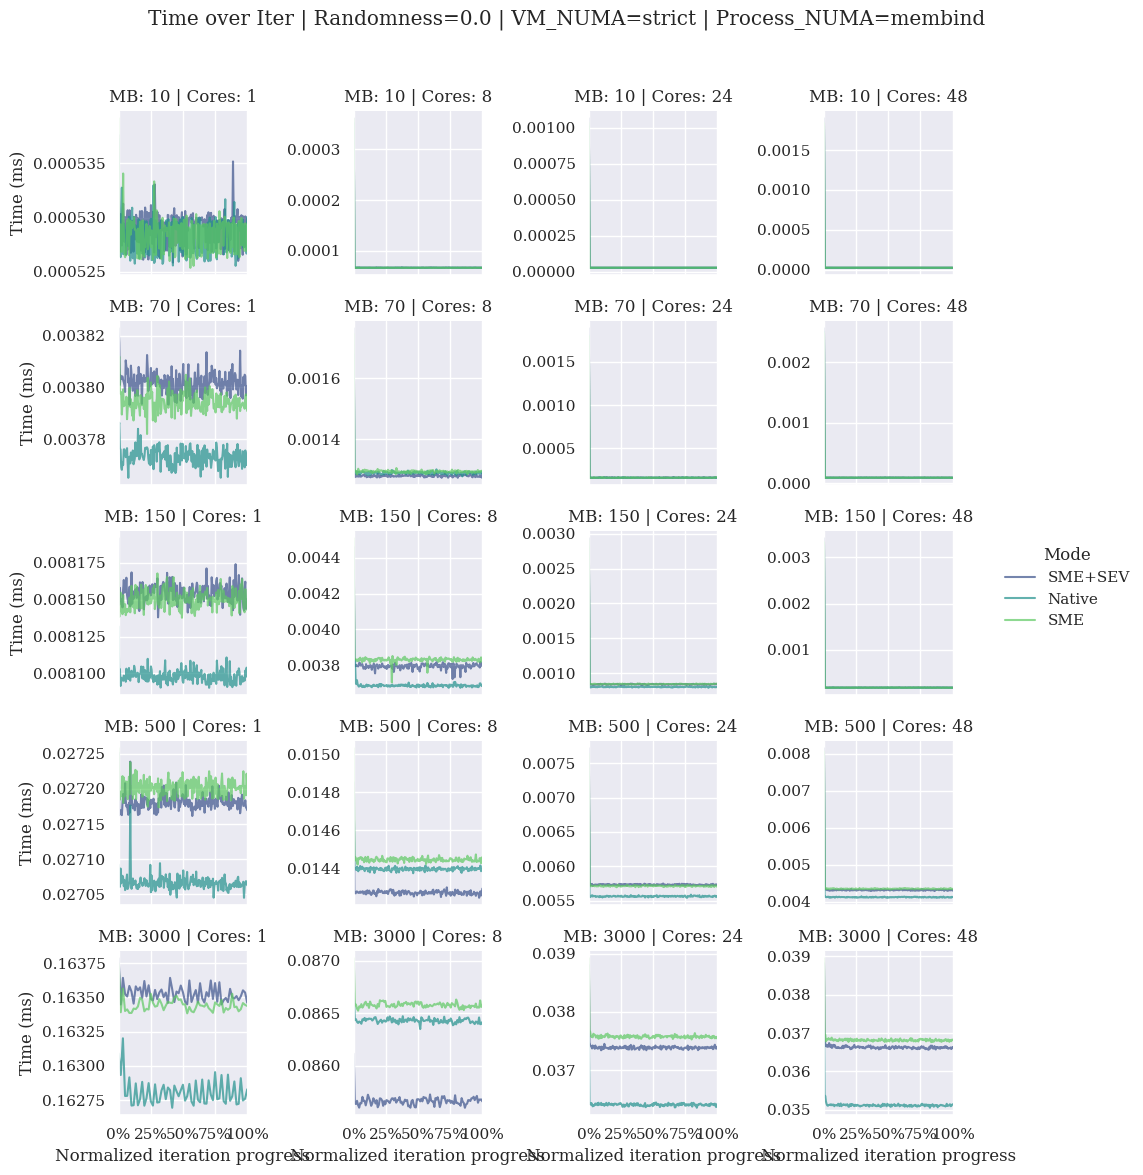

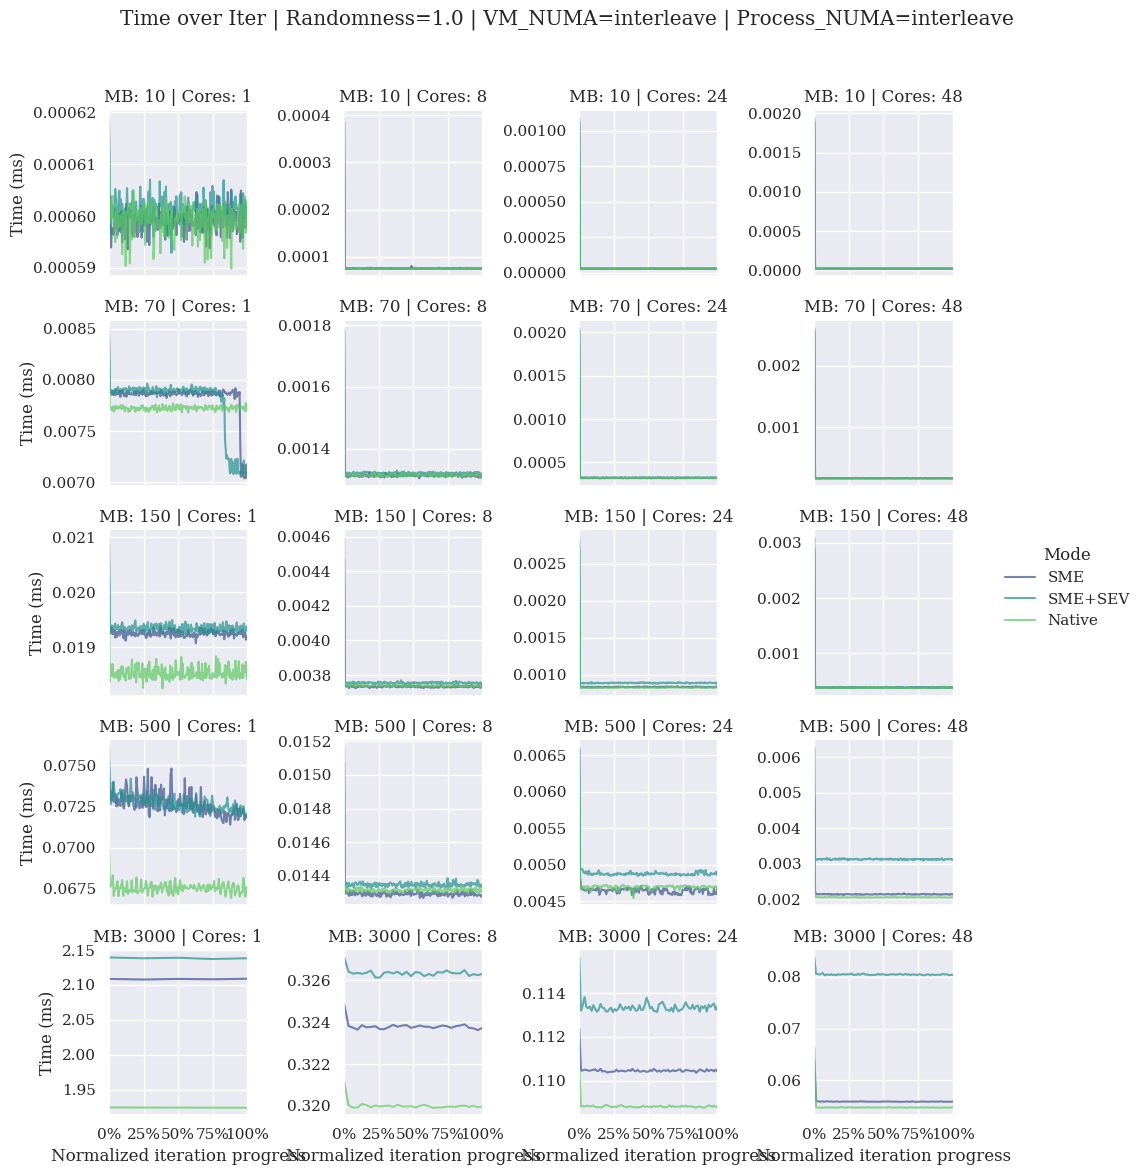

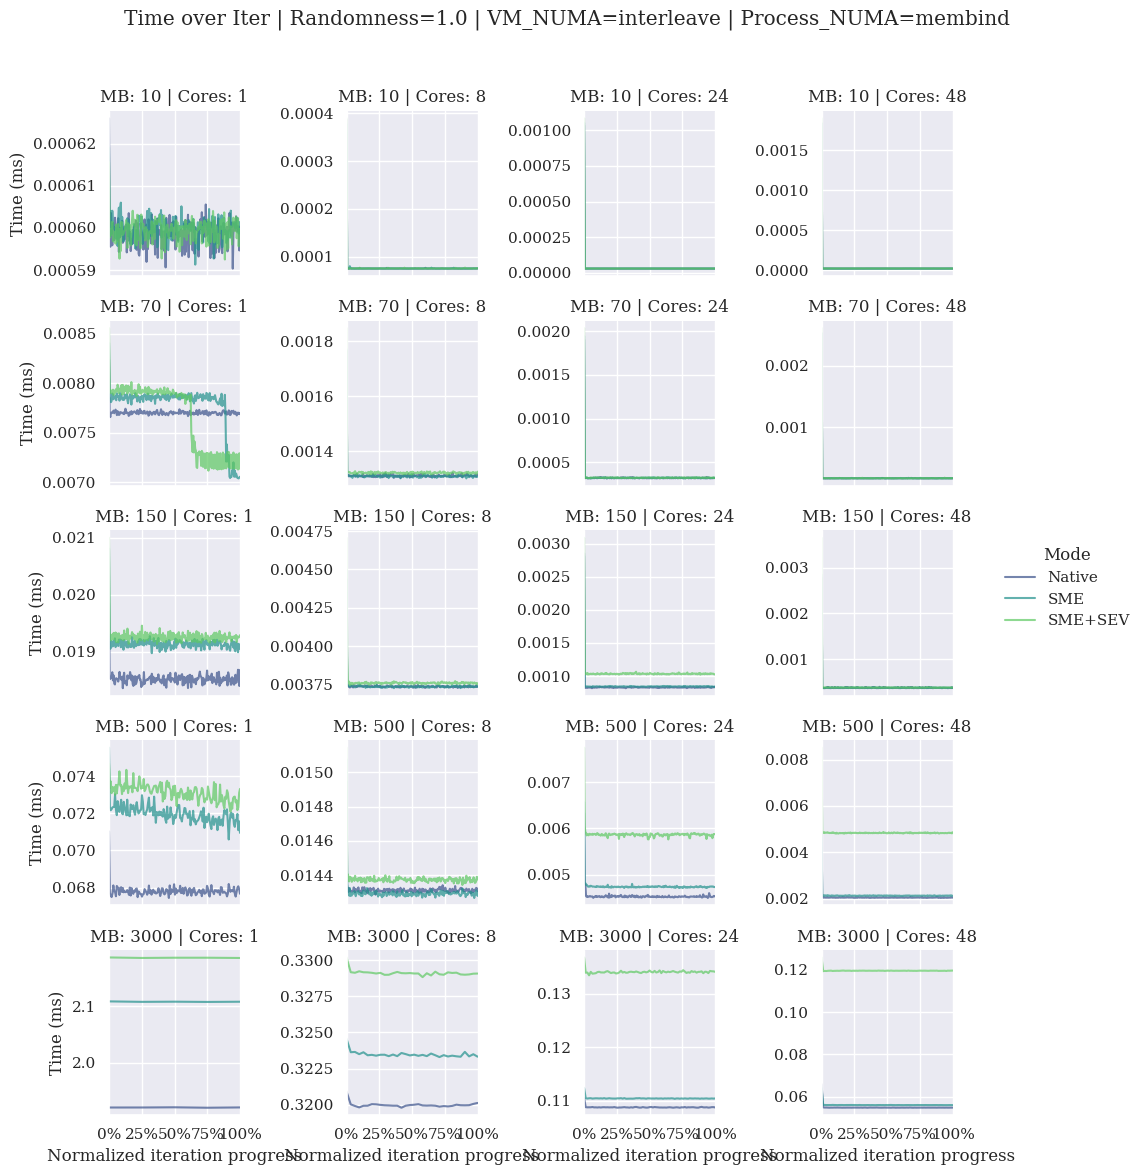

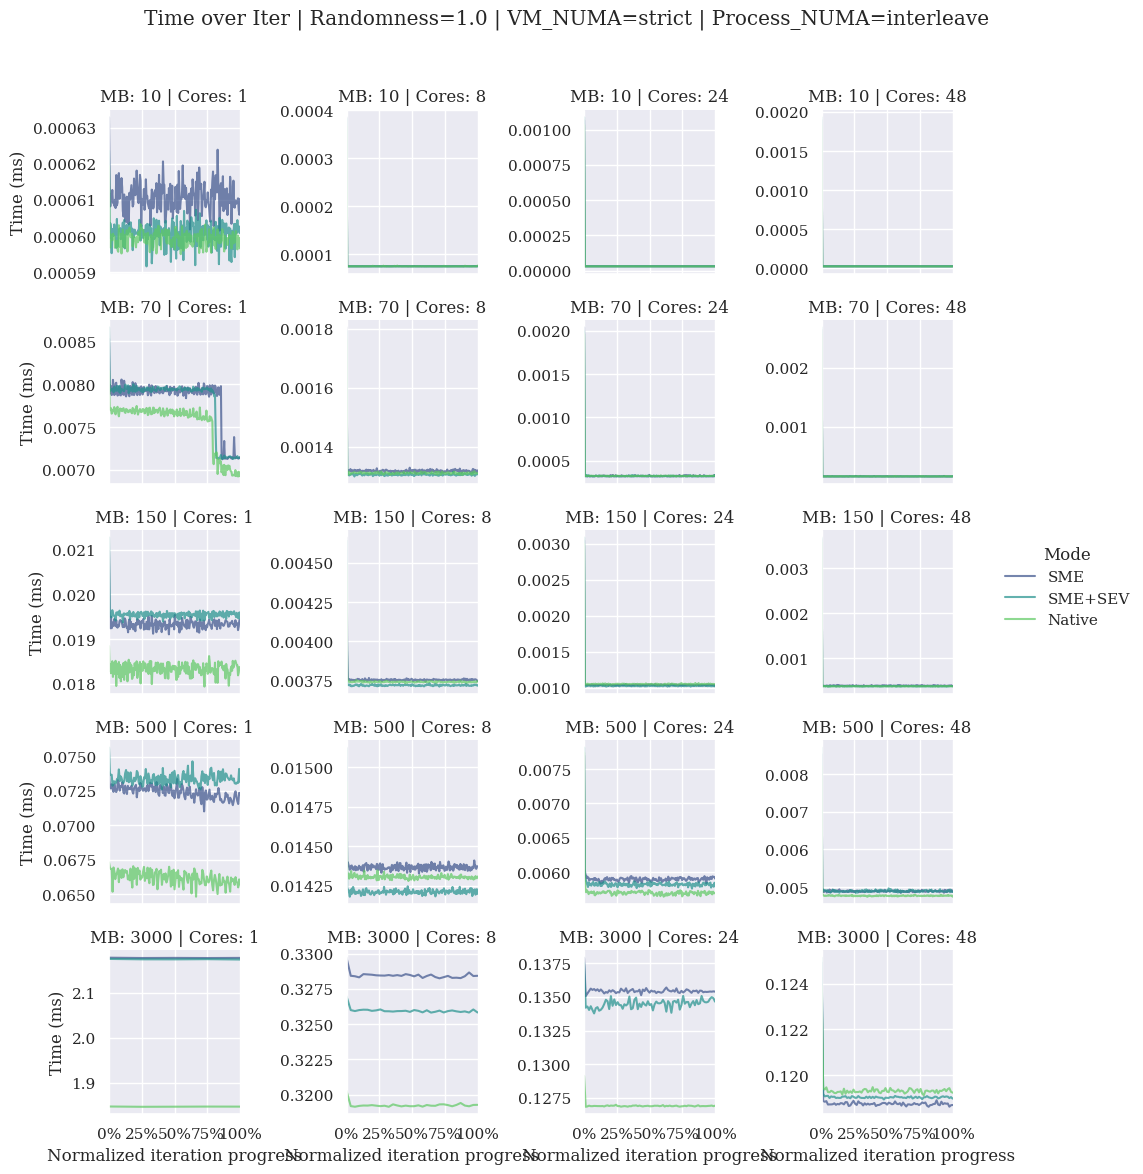

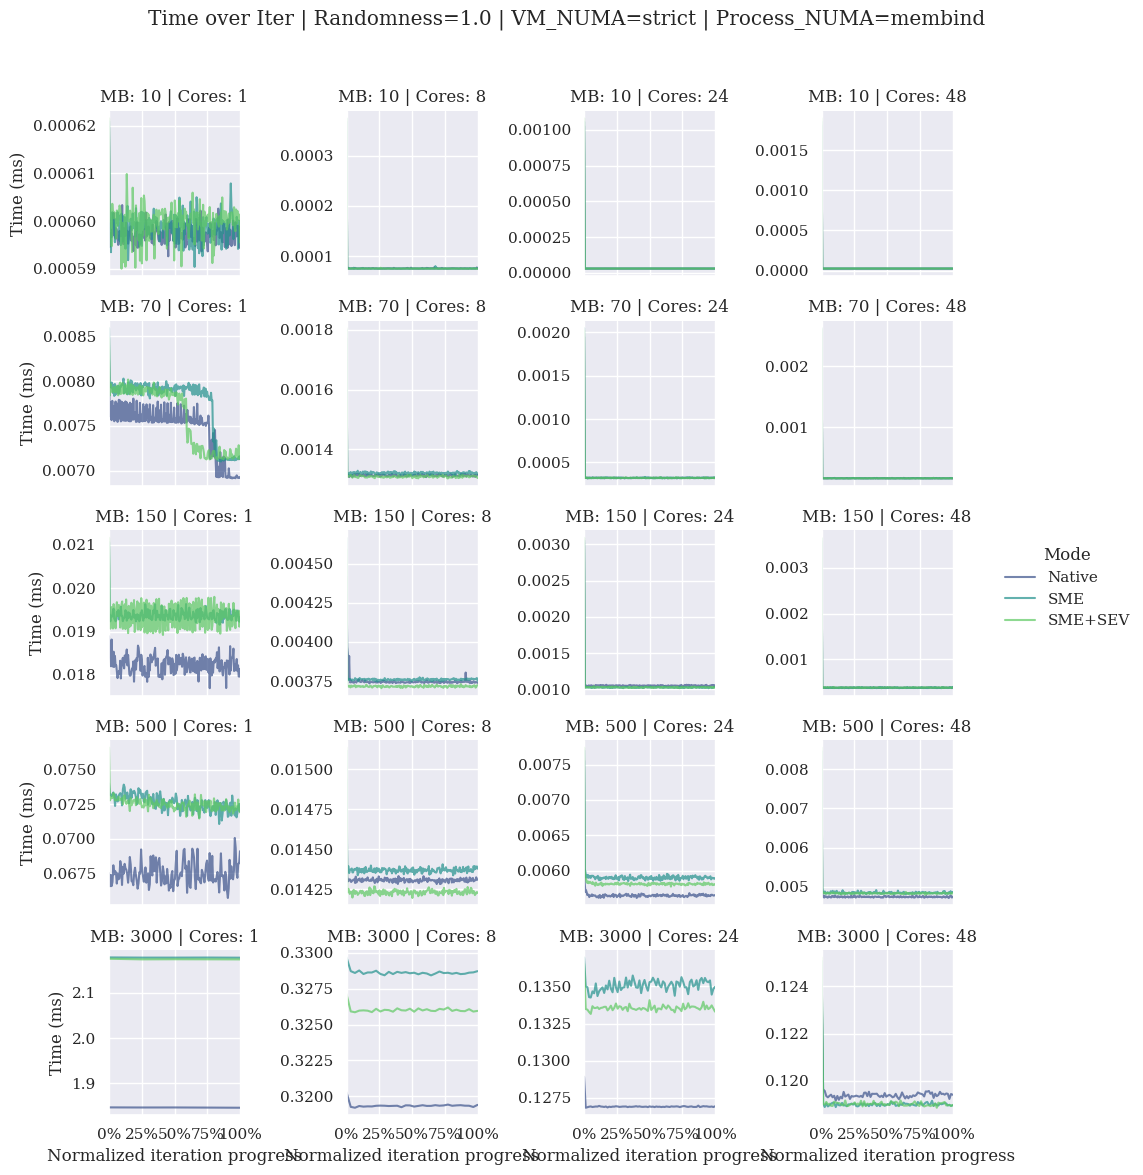

In [33]:
# See visually that most configs are stable

for rnd in sorted(df_iters_small["Randomness"].dropna().unique()):
    for vm in sorted(df_iters_small["VM_NUMA"].dropna().unique()):
        for proc in sorted(df_iters_small["Process_NUMA"].dropna().unique()):
            sub = df_iters_small[
                (df_iters_small["Randomness"] == rnd) &
                (df_iters_small["VM_NUMA"] == vm) &
                (df_iters_small["Process_NUMA"] == proc)
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("IterNorm")

            g = sns.relplot(
                data=sub,
                kind="line",
                x="IterNorm",
                y="Time",
                hue="Mode",
                row="MB",
                col="Cores",
                errorbar=None,
                sort=False,
                palette="viridis",
                facet_kws={"sharey": False, "sharex": True},
                alpha=0.7,
                height=2.3,
                aspect=1.1
            )

            g.set_axis_labels("Normalized iteration progress", "Time (ms)")
            g.set_titles("MB: {row_name} | Cores: {col_name}")
            g.set(xlim=(0, 1), xticks=np.linspace(0, 1, 5))
            g.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
            g.fig.suptitle(
                f"Time over Iter | Randomness={rnd} | VM_NUMA={vm} | Process_NUMA={proc}",
                y=1.02
            )
            g.tight_layout()
            plt.show()

Verdict: No configs are excluded.

# Full results

In [2]:
results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    print(f"Checking for {label} at {f_path}...")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        df["Mode"] = label.replace("_interleave", "")
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)

print(f"Loaded {len(df_raw)} raw rows.")

Checking for Native at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/results.csv...
Checking for SME at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/results.csv...
Checking for SME+SEV at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/results.csv...
Checking for Native_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/results.csv...
Checking for SME_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/results.csv...
Checking for SME+SEV_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/results.csv...
Loaded 7200 raw rows.


In [3]:
# Iterations is in here, because it does not change per config and this simply keeps the column
config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Iterations"]
metric_cols_raw = [ "IO_Time", "SpMV_Time", "Perf_Cycles", "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses" ]

config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = df_raw.groupby(config_cols_raw).apply(iqr_mark_outliers, include_groups=False).reset_index()

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metric_cols_raw)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metric_cols_raw)) * 100:.2f}%")

Total metric data points: 43200
Total data points removed: 2182
Data points removed (%): 5.05%


<Figure size 1600x400 with 0 Axes>

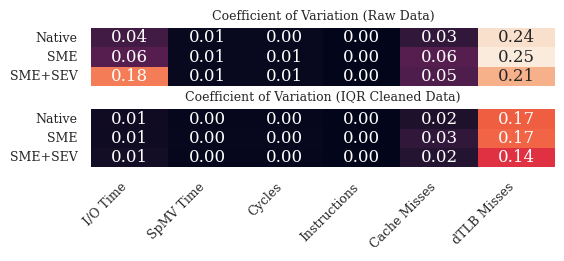

In [4]:
def compute_cv_per_mode(df, config_cols_raw, metrics):
    stats = (
        df
        .groupby(config_cols_raw)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols_raw, metric_cols_raw)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols_raw, metric_cols_raw)

rename_dict = {
	"IO_Time": "I/O Time",
	"SpMV_Time": "SpMV Time",
	"Perf_Cycles": "Cycles",
    "Perf_Instructions": "Instructions",
    "Perf_CacheMisses": "Cache Misses",
    "Perf_dTLBMisses": "dTLB Misses",
}

plt.figure(figsize=(16, 4))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True , gridspec_kw={'right': 0.85})


v_max = max(cv_raw_mode.max().max(), cv_clean_mode.max().max())

kwargs = dict(
    annot=True,
    fmt=".2f",
    cbar=False,
    vmin=0,
    vmax=v_max,
)


sns.heatmap(cv_raw_mode.rename(columns=rename_dict), ax=ax1, **kwargs)
ax1.set_title("Coefficient of Variation (Raw Data)", fontsize=9)
ax1.set_ylabel("")
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=9)

sns.heatmap(cv_clean_mode.rename(columns=rename_dict), ax=ax2, **kwargs)
ax2.set_title("Coefficient of Variation (IQR Cleaned Data)", fontsize=9)
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=9)

plt.subplots_adjust(hspace=0.4, top=0.4)
plt.savefig("images/cv_heatmap_raw_vs_clean.pdf", bbox_inches='tight')

In [5]:
# fully cleaned data grouped by config, median of runs
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

df['N'] = df['Matrix'].str.extract(r'N(\d+)').astype(int)
r = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float)
df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
k = 30  # nnz per row
#2 operations per non-zero element (multiply and add)
# TODO: the cpp gflops were calculated wrong, delete everything regarding that
df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
#based on 32MB L3 per 8 cores
L3_size = {
    1: 32,
    8: 32,
    24: 96,
    48: 192,
}
df['L3_fit'] = df['MB'] <= df['Cores'].map(L3_size)
df["Perf_IPC"] = df['Perf_Instructions'] / df['Perf_Cycles']
df.drop(columns=["N","Matrix"], inplace=True)

config_cols = ["Mode", "MB", "Randomness", "Cores", "Process_NUMA", "VM_NUMA", "L3_fit"]
metric_cols = metric_cols_raw + ["SpMV_GFLOPS", "Perf_IPC"]

df.head()

,Mode,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Randomness,MB,SpMV_GFLOPS,L3_fit,Perf_IPC
0,Native,1,interleave,interleave,369,0.081600,9.948239,3.613565e+10,1.993093e+11,3298979.0,364995.0,0.0,500,3.205531,False,5.515586
1,Native,1,interleave,strict,369,0.082036,9.993071,3.630054e+10,1.993093e+11,3276049.0,395074.5,0.0,500,3.191150,False,5.490532
2,Native,1,membind,interleave,369,0.081796,9.945920,3.612669e+10,1.993093e+11,3276159.0,345223.0,0.0,500,3.206279,False,5.516955
3,Native,1,membind,strict,369,0.081642,9.991050,3.630536e+10,1.993093e+11,3250803.0,344848.0,0.0,500,3.191796,False,5.489804
4,Native,8,interleave,interleave,713,0.081595,10.267954,2.962630e+11,3.852660e+11,16812143.0,16328.0,0.0,500,6.001026,False,1.300419


In [6]:
merge_cols = [c for c in config_cols if c != "Mode"]

df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

df_merged = df_other.merge(
    df_native,
    on=merge_cols,
    suffixes=('', '_native')
)
result = df_merged.copy()

for m in metric_cols:
    native_col = f"{m}_native"

    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )

overhead_df = result

Dimensions to visualize per Metric
Mode - 2 values
Matrix MB - 5 values
Matrix Randomness - 2 values
Cores - 4 values
VM NUMA Policy - 2 values
Process NUMA Policy - 2 values
= 6 Dimensions with 320 configs (cut down from 480 configs with the overhead_df)

How to visualize that?

In [7]:
overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].aggregate(['mean', 'median'])

,mean,median
Mode,,
SME,-1.613351,-0.435216
SME+SEV,-4.756272,-0.766256


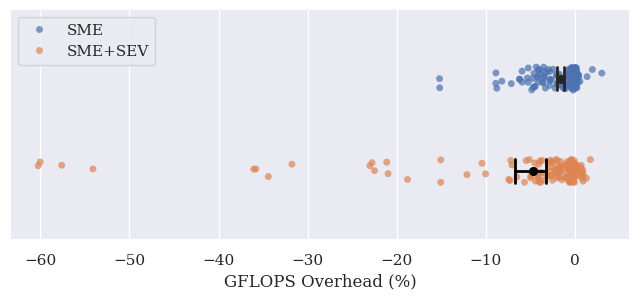

In [8]:
DODGE_VAL = 0.4 

plt.figure(figsize=(8, 3))
sns.pointplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    hue="Mode", 
    dodge=DODGE_VAL, 
    linestyle=None,
    markersize=5,        
    linewidth=2,             
    capsize=0.1,
    palette="dark:black",
	legend=False,
	zorder=2
)

ax = sns.stripplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    hue="Mode", 
    dodge=DODGE_VAL,   
    alpha=0.7,
	zorder=1
)

plt.legend(title=None, loc='upper left')
plt.xlabel("GFLOPS Overhead (%)")
plt.ylabel("")
plt.savefig("images/GFLOPS_Overhead_Distribution.pdf", bbox_inches='tight')

In [9]:
count = (overhead_df["SpMV_GFLOPS_pct"] > 1).sum()
total = overhead_df["SpMV_GFLOPS_pct"].count()
count2 = (overhead_df["SpMV_GFLOPS_pct"] > 0).sum()
total2 = overhead_df["SpMV_GFLOPS_pct"].count()

print(f"Encrypted outperforms native by > 1%: {count} / {total} = {count / total}")
print(f"Encrypted outperforms native by > 0%: {count2} / {total2} = {count2 / total2}")

Encrypted outperforms native by > 1%: 5 / 320 = 0.015625
Encrypted outperforms native by > 0%: 54 / 320 = 0.16875


In [10]:
count_SME_low_impact = ((overhead_df["Mode"] == "SME") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SME = (overhead_df["Mode"] == "SME").sum()
count_SEV_low_impact = ((overhead_df["Mode"] == "SME+SEV") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SEV = (overhead_df["Mode"] == "SME+SEV").sum()
print(f"SME low impact (> -1%): {count_SME_low_impact} / {total_SME} = {count_SME_low_impact / total_SME}")
print(f"SME+SEV low impact (> -1%): {count_SEV_low_impact} / {total_SEV} = {count_SEV_low_impact / total_SEV}")

SME low impact (> -1%): 99 / 160 = 0.61875
SME+SEV low impact (> -1%): 83 / 160 = 0.51875


→ MB:
Mode    SME  SME+SEV
MB                  
10.0   -0.9     -1.3
70.0   -0.7     -0.6
150.0  -1.3     -2.9
500.0  -2.3     -9.2
3000.0 -2.9     -9.9
------------------------------------------------------------
→ Randomness:
Mode        SME  SME+SEV
Randomness              
0.0        -1.0     -4.3
1.0        -2.2     -5.2
------------------------------------------------------------
→ Cores:
Mode   SME  SME+SEV
Cores              
1.0   -2.9     -3.0
8.0   -0.4     -0.3
24.0  -1.6     -5.0
48.0  -1.6    -10.7
------------------------------------------------------------
→ VM NUMA:
Mode        SME  SME+SEV
VM_NUMA                 
interleave -0.9     -7.6
strict     -2.4     -1.9
------------------------------------------------------------
→ Process NUMA:
Mode          SME  SME+SEV
Process_NUMA              
interleave   -1.7     -3.4
membind      -1.6     -6.1
------------------------------------------------------------


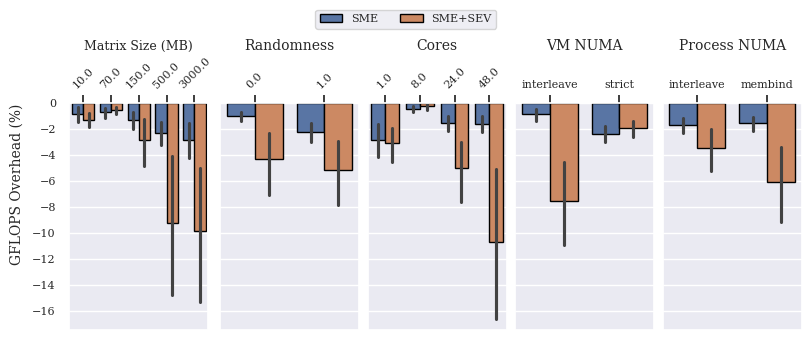

In [53]:
def plot_metric_by_dimensions(metric, metric_legend_name, top):
    all_dims = ['MB', 'Randomness','Cores', 'VM_NUMA', 'Process_NUMA'] 

    fig, axes = plt.subplots( nrows=1, ncols=len(all_dims), figsize=(8, 3), constrained_layout=True, sharey=True) 

    fig.supylabel(f"{metric_legend_name} Overhead (%)", fontsize=10)
    for ax, a in zip(axes, all_dims):
        sns.barplot( data=overhead_df, x=a, y=metric, hue='Mode', errorbar=('ci',95), edgecolor='black', ax=ax)

        if a=="MB":
            ax.set_title("Matrix Size (MB)",y=1.2, fontsize=9)
        else:
            ax.set_title(a.replace("_", " "),y=1.2, fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ['VM_NUMA', 'Process_NUMA'] else 45
        ax.tick_params(axis='x', rotation=rotation, labelsize=8)
        if top:
            ax.xaxis.set_ticks_position('top')
            ax.xaxis.set_label_position('top')
        else:
            ax.xaxis.set_ticks_position('bottom')
            ax.xaxis.set_label_position('bottom')
        ax.tick_params(axis='y', labelsize=8)
        ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)
    fig.savefig("images/overhead_by_dimension_SpMV_GFLOPS_pct.pdf", bbox_inches='tight')

    for dim in all_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (overhead_df.groupby([dim, 'Mode'])[metric]
                   .mean()
                   .round(2)
                   .reset_index())
        
        summary_pivot = summary.pivot(index=dim, columns='Mode', values=metric)
        
        print(summary_pivot.to_string(float_format="{:.1f}".format))
        print("-" * 60)

plot_metric_by_dimensions("SpMV_GFLOPS_pct", "GFLOPS", top=True)

In [12]:
import statsmodels.api as sm
from statsmodels.formula.api import ols


targets = [
#    "IO_Time_pct",
#    "SpMV_Time_pct",
#    "Perf_Cycles_pct",
#    "Perf_Instructions_pct",
#    "Perf_CacheMisses_pct",
#    "Perf_dTLBMisses_pct",
    "SpMV_GFLOPS_pct"
]

# ---------------- ANOVA ----------------
def full_anova(df, target):
    d = df.dropna(subset=[ target, "MB", "Cores", "Randomness", "Process_NUMA", "VM_NUMA"]).copy()

	# C for categorical, handled internally by statsmodels
    formula = f"{target} ~ MB + C(Randomness) + Cores + C(Process_NUMA) + C(VM_NUMA)"

    model = ols(formula, data=d).fit()

    #https://md.psych.bio.uni-goettingen.de/mv/unit/lm_cat/lm_cat_unbal_ss_explained.html
    table = sm.stats.anova_lm(model, typ=3)

    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()

    return table.sort_values("eta_sq", ascending=False)

# ---------------- RUN ----------------
def run(df):
    df["MB"] = pd.to_numeric(df["MB"], errors="coerce").astype("float64")
    df["Cores"] = pd.to_numeric(df["Cores"], errors="coerce").astype("float64")
    df["Randomness"] = pd.to_numeric(df["Randomness"], errors="coerce").astype("float64")

    print("Rows:", len(df))

    results = {}

    for t in targets:

        anova_sme = full_anova(df[df["Mode"] == "SME"].copy(), t)
        anova_sev = full_anova(df[df["Mode"] == "SME+SEV"].copy(), t)
        results[t] = anova_sme
        results[t] = anova_sev

        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME")
        print("="*60)
        print(anova_sme)
        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME+SEV")
        print("="*60)
        print(anova_sev)

    return results


results = run(overhead_df)

Rows: 320

TARGET: SpMV_GFLOPS_pct MODE: SME
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         877.132548  154.0        NaN       NaN  0.793543
C(VM_NUMA)        86.968057    1.0  15.269164  0.000139  0.078680
MB                79.699366    1.0  13.992985  0.000258  0.072104
C(Randomness)     57.931618    1.0  10.171176  0.001728  0.052411
Cores              3.140076    1.0   0.551310  0.458914  0.002841
C(Process_NUMA)    0.451741    1.0   0.079313  0.778608  0.000409
Intercept          0.014394    1.0   0.002527  0.959971  0.000013

TARGET: SpMV_GFLOPS_pct MODE: SME+SEV
                       sum_sq     df          F    PR(>F)    eta_sq
Residual         14049.828867  154.0        NaN       NaN  0.738155
Cores             1991.346132    1.0  21.827120  0.000006  0.104622
MB                1416.685082    1.0  15.528268  0.000123  0.074430
C(VM_NUMA)        1269.072257    1.0  13.910285  0.000269  0.066675
C(Process_NUMA)    277.929455    1.0   3.046381 

Analyze those configurations with high impact.

In [13]:
def top_10_percent_per_mode(df, value_col):
    return df[
        df.groupby("Mode")[value_col]
          .transform(lambda x: x.rank(method="first", ascending=True)
                               <= int(len(x) * 0.1))
    ]

cutoffs = overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].apply(
    lambda x: x.nsmallest(int(len(x) * 0.1)).max()
)

print(cutoffs)

top_configs = top_10_percent_per_mode(overhead_df, "SpMV_GFLOPS_pct")

result_df = (
    top_configs
    .melt(id_vars=["Mode"], value_vars=config_cols,
          var_name="Metric", value_name="Value")
    .groupby(["Mode", "Metric", "Value"])
    .size()
    .reset_index(name="Count")
)

result_df["Representation"] = (
    result_df.groupby(["Mode", "Metric"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

result_df = result_df.sort_values(
    ["Mode", "Metric", "Representation"],
    ascending=[True, True, False]
)

n_levels = overhead_df[config_cols].nunique()

result_df["Expected"] = result_df["Metric"].map(lambda m: 1 / n_levels[m])

result_df["Lift"] = (
    result_df["Representation"] / 100
) / result_df["Expected"]

result_df

Mode
SME        -4.723854
SME+SEV   -15.060995
Name: SpMV_GFLOPS_pct, dtype: float64


,Mode,Metric,Value,Count,Representation,Expected,Lift
0,SME,Cores,1.0,10,62.50,0.25,2.5000
1,SME,Cores,24.0,3,18.75,0.25,0.7500
2,SME,Cores,48.0,3,18.75,0.25,0.7500
3,SME,L3_fit,0.0,14,87.50,0.50,1.7500
4,SME,L3_fit,1.0,2,12.50,0.50,0.2500
9,SME,MB,3000.0,6,37.50,0.20,1.8750
8,SME,MB,500.0,5,31.25,0.20,1.5625
7,SME,MB,150.0,3,18.75,0.20,0.9375
5,SME,MB,10.0,1,6.25,0.20,0.3125
6,SME,MB,70.0,1,6.25,0.20,0.3125


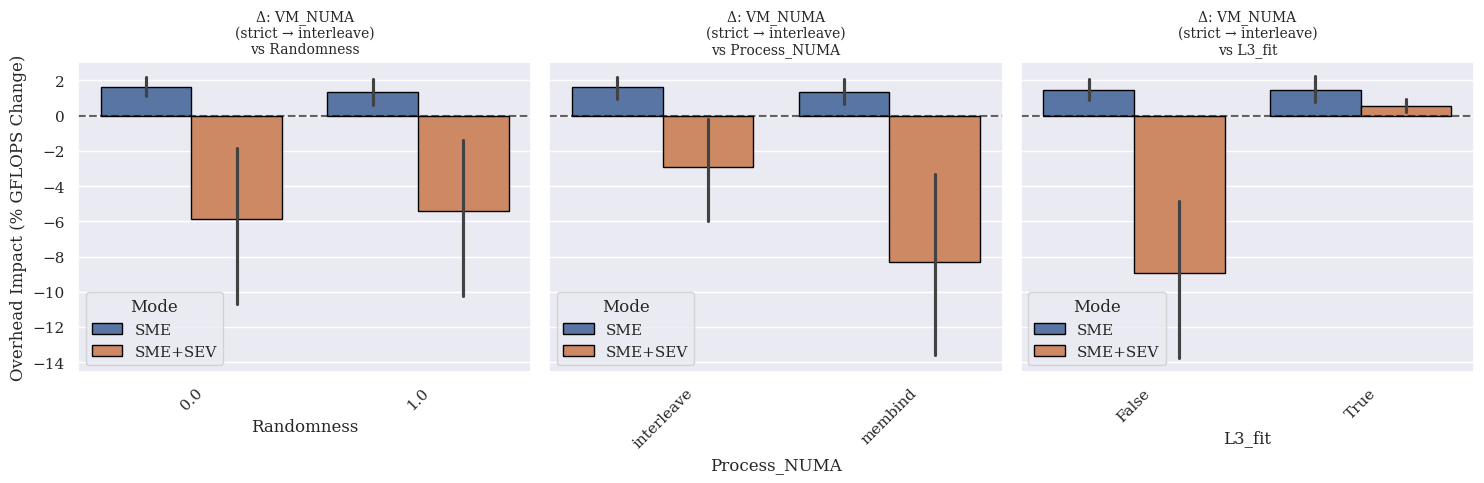

In [14]:
# Global configuration: (Baseline/Low State, Stressed/High State)
# Order matters: Impact = High - Low
DIM_CONFIG = {
    'Randomness': (0, 1),
    'VM_NUMA': ('strict', 'interleave'),
    'Process_NUMA': ('membind', 'interleave'),
    'L3_fit': (False, True),
}

def get_impact_df(df, target_dim):
    """
    Calculates pairwise delta for target_dim using DIM_CONFIG.
    For MB/Cores, it defaults to (min, max).
    """
    all_dims = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Process_NUMA', 'Randomness', 'L3_fit']
    index_cols = [c for c in all_dims if c != target_dim]
    
    # Get comparison values
    if target_dim in DIM_CONFIG:
        low_val, high_val = DIM_CONFIG[target_dim]
    else:
        low_val, high_val = df[target_dim].min(), df[target_dim].max()
    
    # Pivot and calculate Delta
    pivot = df.pivot_table(
        index=index_cols, 
        columns=target_dim, 
        values='SpMV_GFLOPS_pct'
    ).reset_index()
    
    # Impact = 'Stressed' minus 'Baseline'
    pivot['Impact'] = pivot[high_val] - pivot[low_val]
    
    # Store metadata for the plotter to use in titles
    pivot.attrs['comparison'] = f"{low_val} → {high_val}"
    pivot.attrs['target'] = target_dim
    return pivot

def plot_impact_comparison(impact_df, compare_features):
    """
    Plots the impact with automated, descriptive titles.
    """
    target = impact_df.attrs.get('target', 'Dimension')
    comp_str = impact_df.attrs.get('comparison', '')
    
    fig, axes = plt.subplots(1, len(compare_features), figsize=(5 * len(compare_features), 5), sharey=True)
    
    # Ensure axes is always iterable even for 1 plot
    if len(compare_features) == 1: axes = [axes]

    for i, feat in enumerate(compare_features):
        # We pass the full DF to barplot to get automatic error bars (Standard Deviation)
        sns.barplot(
            data=impact_df, 
            x=feat, 
            y='Impact', 
            hue='Mode', 
            edgecolor='black',
            ax=axes[i], 
        )
        
        axes[i].axhline(0, linestyle='--', color='black', alpha=0.6)
        
        # KEY CHANGE: Descriptive Titles
        axes[i].set_title(f"Δ: {target}\n({comp_str})\nvs {feat}", fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        
        if i == 0:
            axes[i].set_ylabel(f"Overhead Impact (% GFLOPS Change)")
        else:
            axes[i].set_ylabel("")
            
    plt.tight_layout()
    plt.show()

rand_df = get_impact_df(overhead_df, 'VM_NUMA')
plot_impact_comparison(rand_df, ["Randomness","Process_NUMA", "L3_fit"])

L3_fit  Mode   
False   SME       -2.065545
        SME+SEV   -6.775735
True    SME       -0.773562
        SME+SEV   -1.005839
Name: SpMV_GFLOPS_pct, dtype: float64


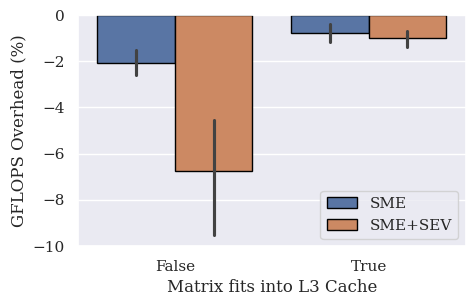

In [41]:
plt.figure(figsize=(5, 3))
sns.barplot(overhead_df, x="L3_fit", y="SpMV_GFLOPS_pct", hue="Mode", edgecolor="black")
plt.legend(title=None)
plt.xlabel("Matrix fits into L3 Cache")
plt.ylabel("GFLOPS Overhead (%)")
plt.savefig("images/overhead_by_L3_fit_SpMV_GFLOPS_pct.pdf", bbox_inches='tight')
print(overhead_df.groupby(["L3_fit", "Mode"])["SpMV_GFLOPS_pct"].mean())

                count      mean       std       sem
Mode    L3_fit                                     
SME     False      52 -1.974823  4.245333  0.588722
        True       28  0.229102  1.334297  0.252158
SME+SEV False      52 -1.408129  4.651669  0.645070
        True       28  0.194466  0.717142  0.135527


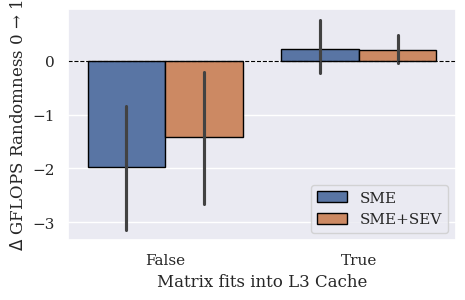

In [50]:
delta_df = (
    overhead_df
    .pivot_table(
        index=["Mode", "L3_fit", "MB", "Cores", "VM_NUMA", "Process_NUMA"],
        columns="Randomness",
        values="SpMV_GFLOPS_pct",
        aggfunc="mean"
    )
    .dropna(subset=[0.0, 1.0])
    .reset_index()
)

delta_df["Delta"] = delta_df[1.0] - delta_df[0.0]

plt.figure(figsize=(5, 3))
sns.barplot( data=delta_df, x="L3_fit", y="Delta", hue="Mode", errorbar=("ci", 95), edgecolor="black")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.legend(title=None)
plt.ylabel("$\\Delta$ GFLOPS Randomness 0 → 1")
plt.xlabel("Matrix fits into L3 Cache")
plt.savefig("images/delta_randomness_by_L3_fit_SpMV_GFLOPS_pct.pdf", bbox_inches="tight")

print(delta_df.groupby(["Mode", "L3_fit"])["Delta"].agg(["count", "mean", "std", "sem"]))

# Additional Counter

In [17]:
from scipy.stats import linregress
res_gflops = linregress(df['Perf_IPC']*df["Cores"], df['SpMV_GFLOPS'])
res_time = linregress(df['Perf_IPC']*df["Cores"], df['SpMV_Time'])
    
print(f'Time: R² = {res_time.rvalue**2:.3f}, GFLOPS: R² = {res_gflops.rvalue**2:.3f}')

Time: R² = 0.002, GFLOPS: R² = 1.000


Mode          SME  SME+SEV
Metric                    
Cache Misses  6.6      6.3
Cycles        1.8      7.5
Instructions -0.1     -0.1
dTLB Misses  -0.1     40.3

------------------------------------------------------------


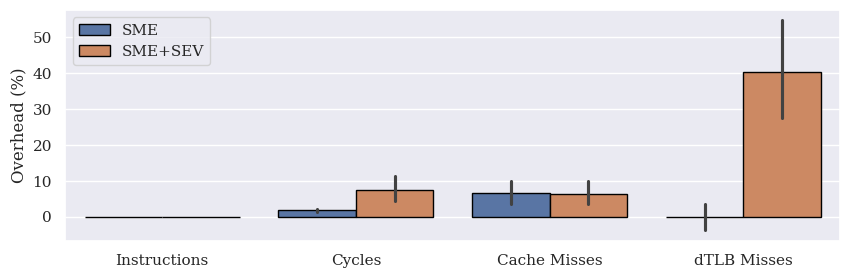

In [43]:
plot_df = overhead_df.melt(
    id_vars=["Mode"],
    value_vars=["Perf_Instructions_pct", "Perf_Cycles_pct", "Perf_CacheMisses_pct", "Perf_dTLBMisses_pct"],
    var_name="Metric",
    value_name="Overhead_pct"
)

plot_df["Metric"] = plot_df["Metric"].map({
    "Perf_Instructions_pct": "Instructions",
    "Perf_Cycles_pct": "Cycles",
    "Perf_CacheMisses_pct": "Cache Misses",
    "Perf_dTLBMisses_pct": "dTLB Misses",
})

plt.figure(figsize=(10, 3))
sns.barplot(data=plot_df, x="Metric", y="Overhead_pct", errorbar=('ci', 95), edgecolor='black', hue="Mode")
plt.legend(title=None)
plt.xlabel("")
plt.ylabel("Overhead (%)")
plt.savefig("images/overhead_by_perf_metric.pdf", bbox_inches='tight')

summary = (plot_df.groupby(['Metric', 'Mode'])['Overhead_pct']
           .mean()
           .round(2)
           .unstack())

print(summary.to_string(float_format="{:.1f}".format))
print("\n" + "-" * 60)

,Pearson(CacheMisses vs GFLOPS_overhead),Spearman(CacheMisses vs GFLOPS_overhead),Pearson(dTLBMisses vs GFLOPS_overhead),Spearman(dTLBMisses vs GFLOPS_overhead),N
Overall,0.020869,-0.123580,0.086725,0.019364,320.0
SME,0.093749,-0.108869,0.068014,0.028627,160.0
SME+SEV,0.008417,-0.126274,0.138309,0.058927,160.0


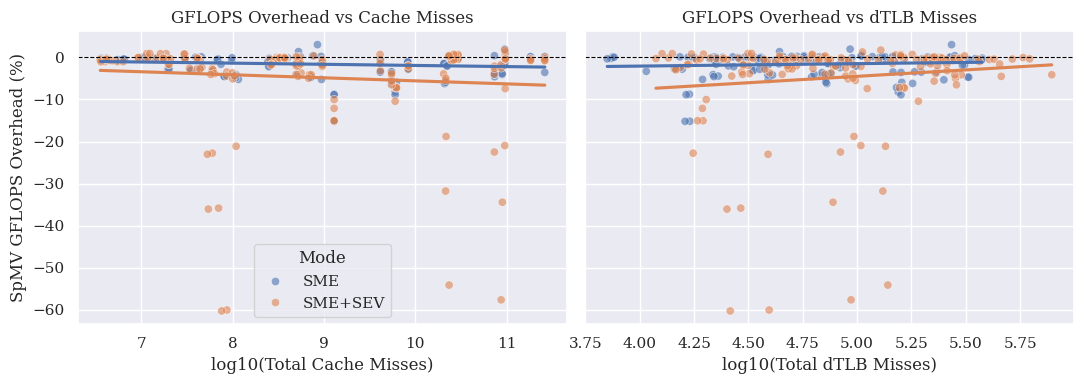

In [56]:
# Correlation between absolute miss counts and SpMV GFLOPS overhead
corr_df = overhead_df[["Mode", "SpMV_GFLOPS_pct", "Perf_CacheMisses", "Perf_dTLBMisses"]].dropna().copy()

# log-scale helper columns (counts are wide-range)
corr_df["log10_CacheMisses"] = np.log10(corr_df["Perf_CacheMisses"].clip(lower=1))
corr_df["log10_dTLBMisses"] = np.log10(corr_df["Perf_dTLBMisses"].clip(lower=1))

# Correlation table (overall + per mode)
def corr_stats(g):
	return pd.Series({
		"Pearson(CacheMisses vs GFLOPS_overhead)": g["Perf_CacheMisses"].corr(g["SpMV_GFLOPS_pct"], method="pearson"),
		"Spearman(CacheMisses vs GFLOPS_overhead)": g["Perf_CacheMisses"].corr(g["SpMV_GFLOPS_pct"], method="spearman"),
		"Pearson(dTLBMisses vs GFLOPS_overhead)": g["Perf_dTLBMisses"].corr(g["SpMV_GFLOPS_pct"], method="pearson"),
		"Spearman(dTLBMisses vs GFLOPS_overhead)": g["Perf_dTLBMisses"].corr(g["SpMV_GFLOPS_pct"], method="spearman"),
		"N": len(g),
	})

corr_overall = corr_stats(corr_df).to_frame(name="Overall").T
corr_by_mode = corr_df.groupby("Mode").apply(corr_stats, include_groups=False)
corr_result = pd.concat([corr_overall, corr_by_mode], axis=0)

display(corr_result)

# Scatter + trend lines
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sns.scatterplot(
	data=corr_df, x="log10_CacheMisses", y="SpMV_GFLOPS_pct",
	hue="Mode", alpha=0.6, ax=axes[0]
)
for m, sub in corr_df.groupby("Mode"):
	sns.regplot(
		data=sub, x="log10_CacheMisses", y="SpMV_GFLOPS_pct",
		scatter=False, ci=None, ax=axes[0], label=f"{m} trend"
	)
axes[0].set_title("GFLOPS Overhead vs Cache Misses")
axes[0].set_xlabel("log10(Total Cache Misses)")
axes[0].set_ylabel("SpMV GFLOPS Overhead (%)")
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)

sns.scatterplot(
	data=corr_df, x="log10_dTLBMisses", y="SpMV_GFLOPS_pct",
	hue="Mode", alpha=0.6, ax=axes[1], legend=False
)
for m, sub in corr_df.groupby("Mode"):
	sns.regplot(
		data=sub, x="log10_dTLBMisses", y="SpMV_GFLOPS_pct",
		scatter=False, ci=None, ax=axes[1]
	)
axes[1].set_title("GFLOPS Overhead vs dTLB Misses")
axes[1].set_xlabel("log10(Total dTLB Misses)")
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

In [40]:
grouped = overhead_df.groupby("Mode")["Perf_dTLBMisses_pct"]

result = grouped.agg(['mean', 'sem'])

result['ci95_low'] = result['mean'] - 1.96 * result['sem']
result['ci95_high'] = result['mean'] + 1.96 * result['sem']

result

,mean,sem,ci95_low,ci95_high
Mode,,,,
SME,-0.118675,1.977204,-3.993996,3.756645
SME+SEV,40.278668,7.147896,26.268792,54.288543


# IO Analysis

Mode     MB    
SME      10.0       3.762282
         70.0       6.541224
         150.0      7.040207
         500.0      7.128418
         3000.0     8.245188
SME+SEV  10.0       4.113318
         70.0       7.937879
         150.0      8.795880
         500.0      9.552155
         3000.0    10.576922
Name: IO_Time_pct, dtype: float64


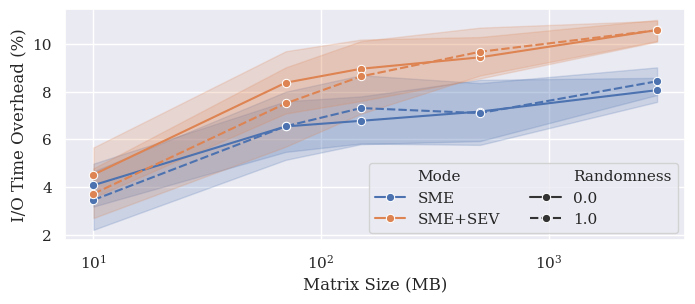

In [21]:
#Randomness does not have a significant impact on I/O time overhead
plt.figure(figsize=(8, 3))
sns.lineplot(data=overhead_df, x="MB", y="IO_Time_pct", marker="o", hue="Mode", style="Randomness")
plt.xscale("log")
plt.xlabel("Matrix Size (MB)")
plt.ylabel("I/O Time Overhead (%)")
plt.legend(ncol=2)
plt.savefig("images/IO_Time_Overhead_by_MB.pdf", bbox_inches='tight')
print(overhead_df.groupby(["Mode", "MB"])["IO_Time_pct"].mean())